In [55]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

In [13]:
df = pd.read_csv("D:\Data Analysis Projects\CSV files\synthetic_it_support_tickets.csv")
df.head()

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,initial_message,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region
0,TCKT_000001,2024-01-31T05:14:27,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,Reset account credentials and confirmed succes...,36.53,0,very_negative,1,0,android,EU
1,TCKT_000002,2024-10-20T06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,I noticed a suspicious login on my account.,We take security very seriously. Our team is r...,Ticket closed without further action after no ...,238.32,0,neutral,3,0,web,NaN
2,TCKT_000003,2024-06-18T21:35:54,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,The api integration feature is not saving my c...,Thanks for reporting this bug. We will look in...,NaN,NaN,0,neutral,3,0,android,MEA
3,TCKT_000004,2025-12-25T15:59:52,CUST_03557,education,chat,analytics_dashboard,account_access,medium,in_progress,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,NaN,NaN,0,positive,5,1,android,LATAM
4,TCKT_000005,2023-08-27T16:08:33,CUST_09556,enterprise,phone_transcript,login_auth,billing_problem,low,resolved,gold,My invoice amount is incorrect compared to the...,Thanks for reaching out about the billing issu...,Adjusted the invoice and issued a refund where...,61.32,0,very_negative,2,0,web,NaN


In [15]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ticket_id              100000 non-null  object 
 1   created_at             100000 non-null  object 
 2   customer_id            100000 non-null  object 
 3   customer_segment       100000 non-null  object 
 4   channel                100000 non-null  object 
 5   product_area           100000 non-null  object 
 6   issue_type             100000 non-null  object 
 7   priority               100000 non-null  object 
 8   status                 100000 non-null  object 
 9   sla_plan               100000 non-null  object 
 10  initial_message        100000 non-null  object 
 11  agent_first_reply      100000 non-null  object 
 12  resolution_summary     60113 non-null   object 
 13  resolution_time_hours  60113 non-null   float64
 14  reopened               100000 non-nul

,resolution_time_hours,reopened,csat_score,has_attachment
count,60113.000000,100000.000000,100000.000000,100000.000000
mean,45.013123,0.050450,2.241950,0.249520
std,49.202797,0.218873,1.771599,0.432737
min,0.110000,0.000000,0.000000,0.000000
25%,14.880000,0.000000,0.000000,0.000000
50%,29.910000,0.000000,2.000000,0.000000
75%,51.660000,0.000000,4.000000,0.000000
max,239.960000,1.000000,5.000000,1.000000


In [16]:
df.isnull().sum()

ticket_id                    0
created_at                   0
customer_id                  0
customer_segment             0
channel                      0
product_area                 0
issue_type                   0
priority                     0
status                       0
sla_plan                     0
initial_message              0
agent_first_reply            0
resolution_summary       39887
resolution_time_hours    39887
reopened                     0
customer_sentiment           0
csat_score                   0
has_attachment               0
platform                     0
region                   19997
dtype: int64

In [17]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending=False)

resolution_time_hours    39.887
resolution_summary       39.887
region                   19.997
created_at                0.000
platform                  0.000
has_attachment            0.000
csat_score                0.000
customer_sentiment        0.000
reopened                  0.000
agent_first_reply         0.000
ticket_id                 0.000
sla_plan                  0.000
status                    0.000
priority                  0.000
issue_type                0.000
product_area              0.000
channel                   0.000
customer_segment          0.000
customer_id               0.000
initial_message           0.000
dtype: float64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df['ticket_id'].duplicated().sum()

np.int64(0)

In [20]:
df = df.drop_duplicates(subset='ticket_id')

In [21]:
df['created_at'] = pd.to_datetime(df['created_at'])

In [22]:
df['year'] = df['created_at'].dt.year

df['month'] = df['created_at'].dt.month_name()

df['day'] = df['created_at'].dt.day

df['weekday'] = df['created_at'].dt.day_name()

df['hour'] = df['created_at'].dt.hour

df['quarter'] = df['created_at'].dt.quarter

In [23]:
categorical_cols = [
    'customer_segment',
    'channel',
    'product_area',
    'issue_type',
    'priority',
    'status',
    'sla_plan',
    'customer_sentiment',
    'platform',
    'region'
]

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [24]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


customer_segment
['individual' 'small_business' 'education' 'enterprise' 'non_profit']

channel
['email' 'in_app' 'chat' 'phone_transcript' 'web_form']

product_area
['data_export' 'billing' 'api_integration' 'analytics_dashboard'
 'login_auth' 'mobile_app' 'notifications']

issue_type
['account_access' 'security_concern' 'bug' 'billing_problem' 'performance'
 'feature_request' 'how_to' 'other']

priority
['low' 'medium' 'urgent' 'high']

status
['resolved' 'closed_no_action' 'in_progress' 'on_hold' 'open']

sla_plan
['standard' 'gold' 'platinum']

customer_sentiment
['very_negative' 'neutral' 'positive' 'negative' 'very_positive']

platform
['android' 'web' 'ios' 'api_client' 'desktop_app']

region
['eu' 'nan' 'mea' 'latam' 'apac']


In [25]:
df['region'] = df['region'].fillna('unknown')

In [26]:
df['customer_sentiment'] = df['customer_sentiment'].fillna('unknown')

In [27]:
df['csat_score'].isnull().sum()

np.int64(0)

In [28]:
df['resolution_time_hours'].describe()

count    60113.000000
mean        45.013123
std         49.202797
min          0.110000
25%         14.880000
50%         29.910000
75%         51.660000
max        239.960000
Name: resolution_time_hours, dtype: float64

In [29]:
df[df['resolution_time_hours'] < 0]
df[df['resolution_time_hours'] > 200]

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,...,csat_score,has_attachment,platform,region,year,month,day,weekday,hour,quarter
1,TCKT_000002,2024-10-20 06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,...,3,0,web,nan,2024,October,20,Sunday,6,4
5,TCKT_000006,2024-09-24 14:04:53,CUST_03844,education,email,mobile_app,performance,low,closed_no_action,gold,...,5,0,ios,nan,2024,September,24,Tuesday,14,3
20,TCKT_000021,2024-04-06 23:23:31,CUST_02050,individual,phone_transcript,api_integration,feature_request,urgent,closed_no_action,standard,...,0,0,web,apac,2024,April,6,Saturday,23,2
24,TCKT_000025,2024-01-26 17:08:06,CUST_01046,individual,web_form,notifications,how_to,low,closed_no_action,standard,...,5,0,android,eu,2024,January,26,Friday,17,1
129,TCKT_000130,2025-09-06 10:23:53,CUST_09646,individual,web_form,data_export,performance,medium,closed_no_action,standard,...,2,1,ios,nan,2025,September,6,Saturday,10,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99642,TCKT_099643,2022-03-06 18:45:12,CUST_05467,small_business,in_app,data_export,performance,low,closed_no_action,gold,...,5,0,web,mea,2022,March,6,Sunday,18,1
99855,TCKT_099856,2022-02-10 07:31:21,CUST_06198,non_profit,phone_transcript,api_integration,bug,urgent,closed_no_action,standard,...,0,0,android,apac,2022,February,10,Thursday,7,1
99857,TCKT_099858,2024-03-04 13:27:19,CUST_02682,small_business,web_form,billing,how_to,high,closed_no_action,standard,...,0,0,api_client,mea,2024,March,4,Monday,13,1
99871,TCKT_099872,2023-06-19 14:30:27,CUST_07851,non_profit,chat,data_export,other,high,closed_no_action,standard,...,3,1,ios,latam,2023,June,19,Monday,14,2


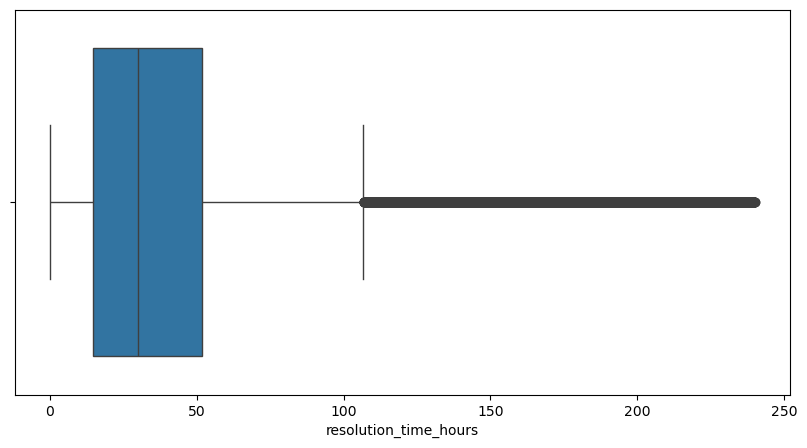

In [30]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['resolution_time_hours'])

plt.show()

In [31]:
df['reopened'].value_counts()
df['has_attachment'].value_counts()

has_attachment
0    75048
1    24952
Name: count, dtype: int64

In [32]:
df['csat_score'].unique()
df[
    (df['csat_score'] < 1) |
    (df['csat_score'] > 5)
]

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,...,csat_score,has_attachment,platform,region,year,month,day,weekday,hour,quarter
7,TCKT_000008,2024-11-07 06:43:26,CUST_00065,non_profit,phone_transcript,api_integration,billing_problem,low,resolved,standard,...,0,0,web,nan,2024,November,7,Thursday,6,4
8,TCKT_000009,2023-08-30 23:04:26,CUST_05893,small_business,phone_transcript,billing,billing_problem,high,resolved,platinum,...,0,0,desktop_app,apac,2023,August,30,Wednesday,23,3
14,TCKT_000015,2025-06-15 10:10:31,CUST_01999,education,chat,mobile_app,feature_request,low,in_progress,standard,...,0,1,api_client,mea,2025,June,15,Sunday,10,2
17,TCKT_000018,2022-12-30 04:11:31,CUST_07778,education,in_app,billing,security_concern,medium,resolved,standard,...,0,0,api_client,latam,2022,December,30,Friday,4,4
19,TCKT_000020,2024-08-24 08:57:46,CUST_08156,enterprise,phone_transcript,billing,account_access,medium,in_progress,standard,...,0,0,android,latam,2024,August,24,Saturday,8,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99988,TCKT_099989,2025-11-27 18:48:25,CUST_01151,small_business,email,notifications,performance,medium,resolved,standard,...,0,1,desktop_app,eu,2025,November,27,Thursday,18,4
99990,TCKT_099991,2024-03-07 10:12:45,CUST_07605,non_profit,in_app,login_auth,billing_problem,medium,resolved,standard,...,0,0,web,latam,2024,March,7,Thursday,10,1
99995,TCKT_099996,2023-05-16 06:23:50,CUST_06828,education,in_app,analytics_dashboard,billing_problem,high,resolved,standard,...,0,0,desktop_app,eu,2023,May,16,Tuesday,6,2
99998,TCKT_099999,2022-06-20 22:29:10,CUST_02290,small_business,email,analytics_dashboard,account_access,low,open,standard,...,0,1,api_client,nan,2022,June,20,Monday,22,2


In [33]:
df['status'].value_counts()
(df['status'].value_counts(normalize=True) * 100)

status
resolved            50.131
in_progress         19.783
on_hold             10.165
closed_no_action     9.982
open                 9.939
Name: proportion, dtype: float64

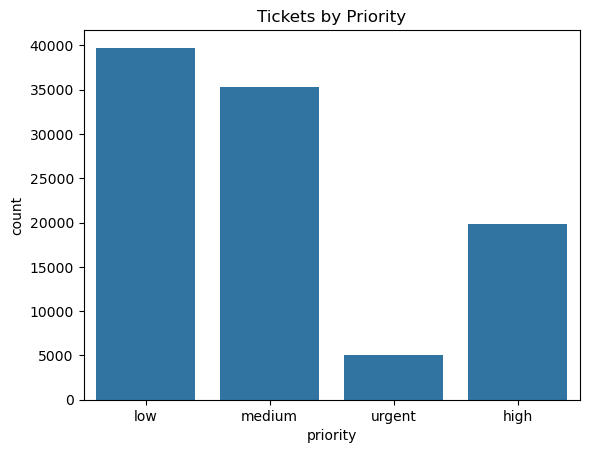

In [34]:
df['priority'].value_counts()
sns.countplot(data=df, x='priority')

plt.title("Tickets by Priority")

plt.show()

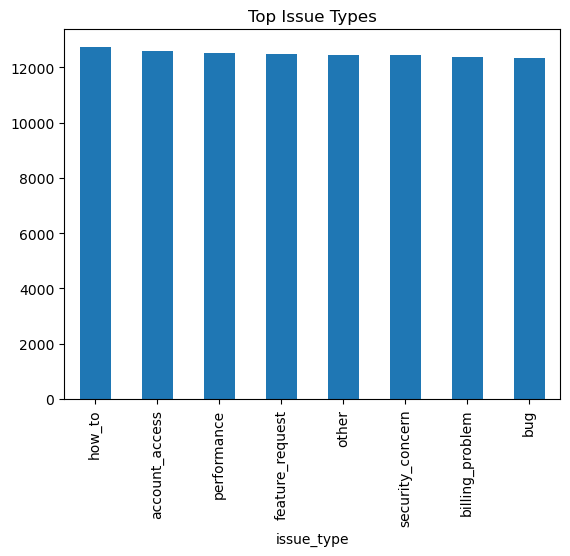

In [35]:
df['issue_type'].value_counts()
top_issues = df['issue_type'].value_counts().head(10)

top_issues.plot(kind='bar')

plt.title("Top Issue Types")

plt.show()

In [36]:
df['product_area'].value_counts()
df.groupby('product_area')['resolution_time_hours'].mean().sort_values()

product_area
data_export            44.423986
notifications          44.425516
billing                44.504376
login_auth             44.725027
analytics_dashboard    44.949447
api_integration        45.894527
mobile_app             46.128047
Name: resolution_time_hours, dtype: float64

In [37]:
df['channel'].value_counts()
df.groupby('channel')['csat_score'].mean().sort_values()
df.groupby('channel')['resolution_time_hours'].mean().sort_values()

channel
web_form            44.434545
in_app              44.952506
phone_transcript    45.123883
email               45.157727
chat                45.397707
Name: resolution_time_hours, dtype: float64

In [38]:
df['customer_segment'].value_counts()
df.groupby('customer_segment')['resolution_time_hours'].mean()

customer_segment
education         44.444417
enterprise        45.788435
individual        44.274989
non_profit        45.180209
small_business    45.371480
Name: resolution_time_hours, dtype: float64

In [39]:
df['region'].value_counts()
df.groupby('region')['resolution_time_hours'].mean()

region
apac     45.865211
eu       44.159969
latam    45.308559
mea      45.355373
nan      44.364429
Name: resolution_time_hours, dtype: float64

In [40]:
df['platform'].value_counts()
df.groupby('platform')['csat_score'].mean()

platform
android        2.225020
api_client     2.238567
desktop_app    2.242068
ios            2.238843
web            2.265119
Name: csat_score, dtype: float64

In [41]:
df['customer_sentiment'].value_counts()
df.groupby('customer_sentiment')['csat_score'].mean()

customer_sentiment
negative         1.747107
neutral          2.456763
positive         3.135574
very_negative    1.045629
very_positive    3.511877
Name: csat_score, dtype: float64

In [44]:
df['reopened'].mean() * 100
df.groupby('reopened')['resolution_time_hours'].mean()
df.groupby('reopened')['csat_score'].mean()

reopened
0    2.244095
1    2.201586
Name: csat_score, dtype: float64

In [46]:
df['sla_breach'] = np.where(
    df['resolution_time_hours'] > 24,
    1,
    0
)

(1 - df['sla_breach'].mean()) * 100

df.groupby('issue_type')['sla_breach'].mean().sort_values(ascending=False)

issue_type
feature_request     0.348362
billing_problem     0.348005
how_to              0.347829
performance         0.346280
other               0.344379
security_concern    0.342671
account_access      0.340075
bug                 0.339704
Name: sla_breach, dtype: float64

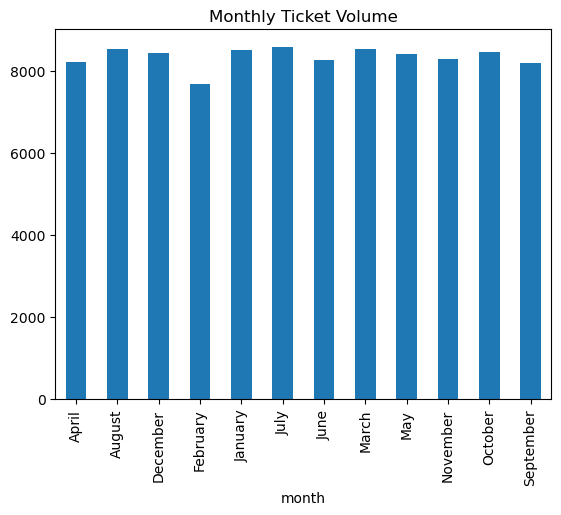

In [47]:
monthly_tickets = df.groupby('month')['ticket_id'].count()

monthly_tickets.plot(kind='bar')

plt.title("Monthly Ticket Volume")

plt.show()

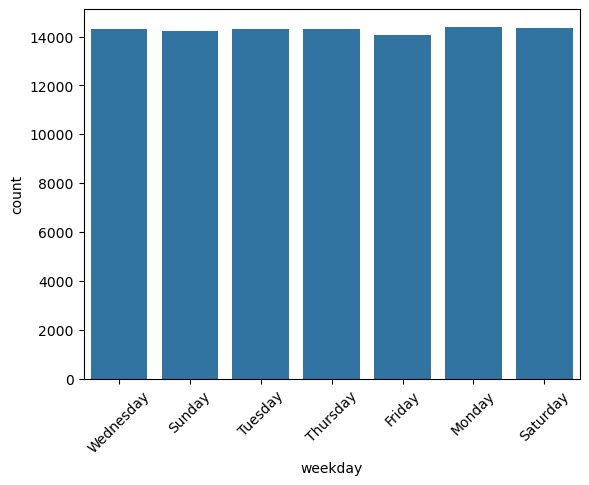

In [48]:
sns.countplot(data=df, x='weekday')

plt.xticks(rotation=45)

plt.show()

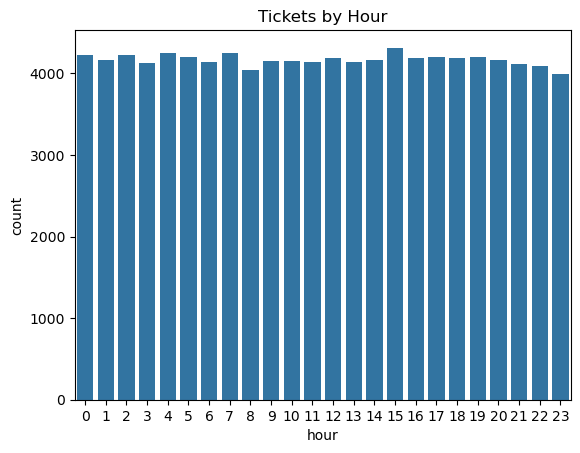

In [49]:
sns.countplot(data=df, x='hour')

plt.title("Tickets by Hour")

plt.show()

In [50]:
numeric_cols = [
    'resolution_time_hours',
    'csat_score',
    'reopened',
    'has_attachment'
]

corr = df[numeric_cols].corr()

corr

,resolution_time_hours,csat_score,reopened,has_attachment
resolution_time_hours,1.000000,-0.000324,0.000853,-0.000504
csat_score,-0.000324,1.000000,-0.005252,0.002098
reopened,0.000853,-0.005252,1.000000,-0.003677
has_attachment,-0.000504,0.002098,-0.003677,1.000000


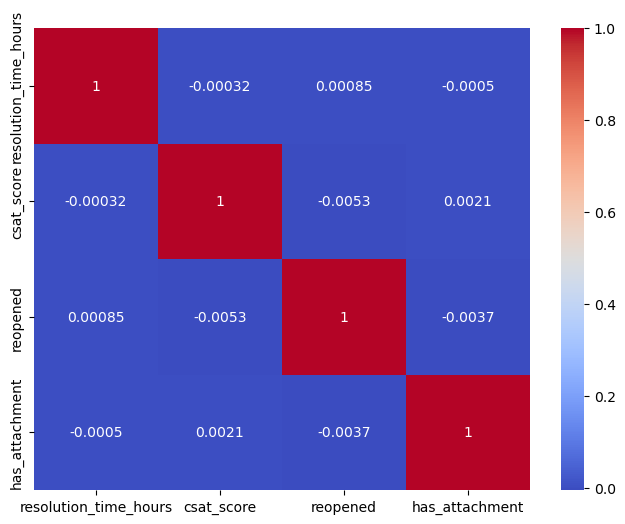

In [51]:
plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.show()

In [52]:
text = " ".join(df['initial_message'].dropna())

words = text.lower().split()

Counter(words).most_common(20)

[('i', 58191),
 ('my', 50240),
 ('the', 45623),
 ('to', 33250),
 ('is', 20841),
 ('can', 16993),
 ('for', 16685),
 ('in', 16635),
 ('a', 16601),
 ('data', 15657),
 ('login', 15413),
 ('you', 12708),
 ('need', 12484),
 ('not', 12473),
 ('export', 9703),
 ('how', 8489),
 ('seems', 8438),
 ('am', 8421),
 ('when', 8413),
 ('and', 8395)]

In [56]:
bins = [0,4,24,72,999]

labels = [
    '<4 hrs',
    '4-24 hrs',
    '1-3 days',
    '3+ days'
]

df['resolution_bucket'] = pd.cut(
    df['resolution_time_hours'],
    bins=bins,
    labels=labels
)

In [57]:
df['ticket_age_days'] = (
    df['resolution_time_hours'] / 24
)

In [59]:
df.to_csv(
    "D:\Data Analysis Projects\CSV files\Cleaned CSV\ITSM_tickets_cleaned.csv",
    index=False
)

In [61]:
cleaned_df = pd.read_csv(
    "D:\Data Analysis Projects\CSV files\Cleaned CSV\ITSM_tickets_cleaned.csv"
)

cleaned_df.head()

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,...,region,year,month,day,weekday,hour,quarter,sla_breach,resolution_bucket,ticket_age_days
0,TCKT_000001,2024-01-31 05:14:27,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,...,eu,2024,January,31,Wednesday,5,1,1,1-3 days,1.522083
1,TCKT_000002,2024-10-20 06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,...,NaN,2024,October,20,Sunday,6,4,1,3+ days,9.930000
2,TCKT_000003,2024-06-18 21:35:54,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,...,mea,2024,June,18,Tuesday,21,2,0,NaN,NaN
3,TCKT_000004,2025-12-25 15:59:52,CUST_03557,education,chat,analytics_dashboard,account_access,medium,in_progress,standard,...,latam,2025,December,25,Thursday,15,4,0,NaN,NaN
4,TCKT_000005,2023-08-27 16:08:33,CUST_09556,enterprise,phone_transcript,login_auth,billing_problem,low,resolved,gold,...,NaN,2023,August,27,Sunday,16,3,1,1-3 days,2.555000
